Copied and slightly modified from Javier Roulet's `cogwheel_catalog/notebooks/1_choose_event_catalogs.ipynb`

In [1]:
%load_ext autoreload
%autoreload 0

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
import time

from cogwheel import data, posterior

import gwosc
import gwpy.table

import sys
sys.path.insert(0, '/Users/abbywilliams/Research/Chicago/GW/code')
from parameter_estimation import get_chirp_mass, get_table_data, check_eventname

In [3]:
# load the dictionary (json) of event configs, or create one if it doesn't exist
config_fn = '../data/event_configs.json'
try:
    with open(config_fn) as file:
        event_configs = json.load(file)
except FileNotFoundError:
    event_configs = {}

In [4]:
# download data from several events
catalog_name = 'GWTC-4.0'

event_tables = gwpy.table.EventTable.fetch_open_data(catalog_name, selection='network_matched_filter_snr > 15')

print(f"found {len(event_tables)} events")
for event_table in event_tables:
    # if there is a version attached to the name in the event table (as 'GWxxxxxx_xxxxxx-vY', we need to remove this
    #    from the name used to get timeseries data
    eventname = event_table['name'].split('-')[0]
    # where to save
    eventpath = f'../data/{catalog_name}/{eventname}'
    # then download the actual time series data (and time it just for kicks)
    print(f"downloading timeseries data for {eventname}...", end=' ')
    s = time.time()
    data.download_timeseries(eventname, outdir=eventpath)
    print(f"done in {time.time() - s:.2f} sec")

found 12 events
downloading timeseries data for GW240105_151143... Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW240105_151143/H_GW240105_151143.hdf5
done in 1.68 sec
downloading timeseries data for GW231226_101520... Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW231226_101520/H_GW231226_101520.hdf5
Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW231226_101520/L_GW231226_101520.hdf5
done in 0.86 sec
downloading timeseries data for GW231206_233901... Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW231206_233901/H_GW231206_233901.hdf5
Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW231206_233901/L_GW231206_233901.hdf5
done in 0.85 sec
downloading timeseries data for GW231123_135430... Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW231123_135430/H_GW231123_135430.hdf5
Skipping existing file /Users/abb

In [5]:
event_tables['name']

GW240105_151143-v1
GW231226_101520-v1
GW231206_233901-v1
GW231123_135430-v2
GW231102_071736-v1
GW231028_153006-v1
GW230927_153832-v1
GW230919_215712-v1
GW230914_111401-v1
GW230814_230901-v1
GW230628_231200-v1


In [49]:
# download data from a single event
eventname = 'GW230627_015337'
catalog_name = 'GWTC-4.0'

# get the table data first to see if there's an issue with the name and catalog
event_table = get_table_data(eventname, catalog_name)
# check our input eventname against the name in the table
eventname = check_eventname(eventname, event_table)

# where to save
eventpath = f'../data/{catalog_name}/{eventname}'

# then download the actual time series data (and time it just for kicks)
print("downloading timeseries data...", end=' ')
s = time.time()
data.download_timeseries(eventname, outdir=eventpath)
print(f"done in {time.time() - s:.2f} sec")

found event for GW230627_015337; updating eventname from GW230627_015337
downloading timeseries data... Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW230627_015337/H_GW230627_015337.hdf5
Skipping existing file /Users/abbywilliams/Research/Chicago/GW/data/GWTC-4.0/GW230627_015337/L_GW230627_015337.hdf5
done in 0.00 sec


found 2 files for GW230627_015337 (GWTC-4.0) in detectors HL
got chirp mass as 6.44 Msun
Searching incoherent solution for GW230627_015337
Set intrinsic parameters, lnL = 406.9061121993065
Set time, lnL(H) = 240.15213696377154
Set sky location, lnL = 408.5313776387591
Set phase and distance, lnL = 408.5313776387591
Set mchirp_range = (6.114940703356103, 6.762380698095034)


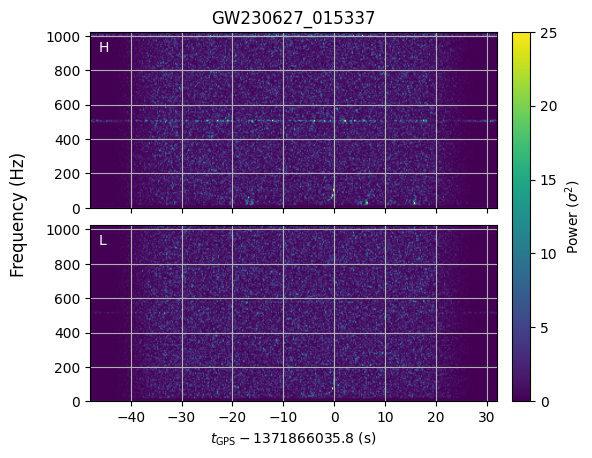

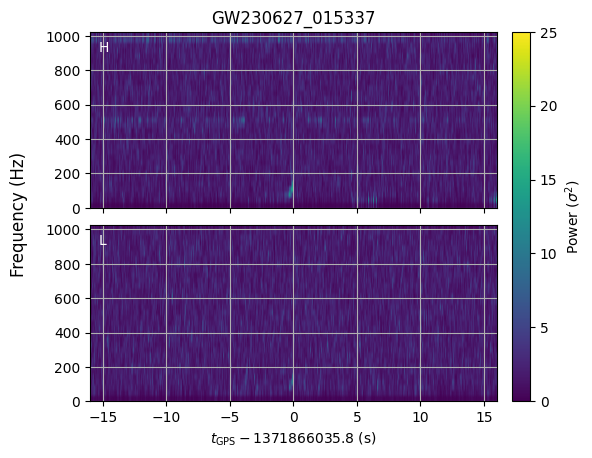

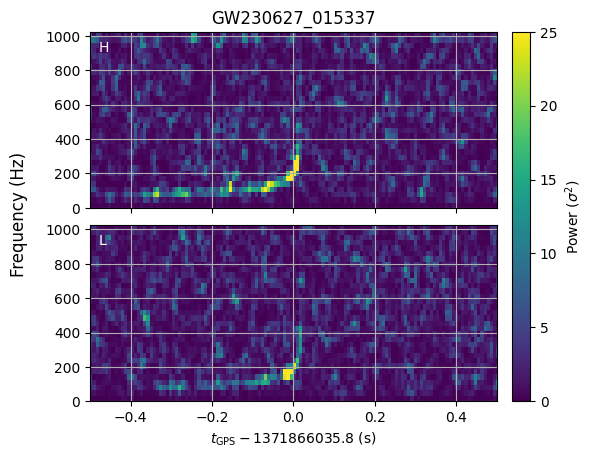

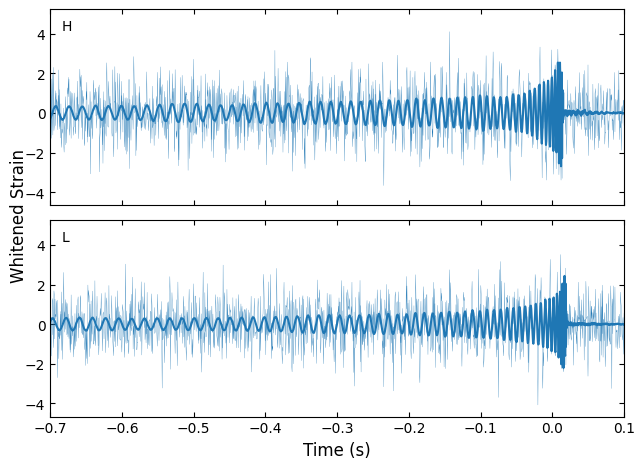

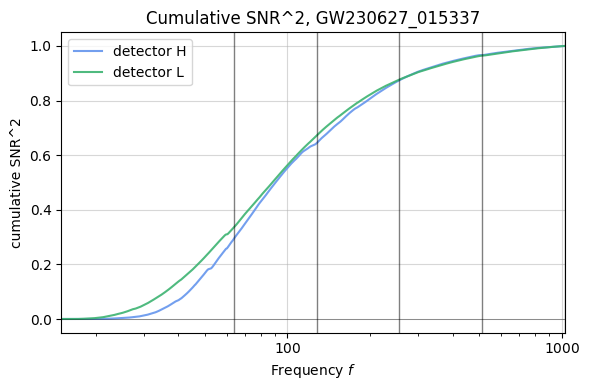

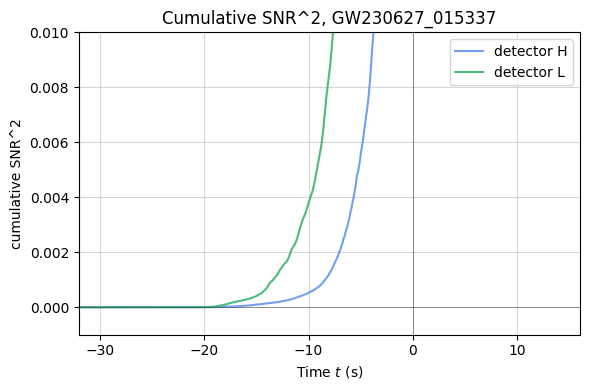

In [51]:
# kwargs for processing the event data: this is what we're testing, to save as the config if we're happy with it!
kwargs = dict(
    fmax = 1024,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)

filenames = sorted(Path(eventpath).glob('*.hdf5'))
assert eventname == Path(eventpath).name
detector_names = ''.join(filename.name[0] for filename in filenames)
print(f"found {len(filenames)} files for {eventname} ({catalog_name}) in detectors {detector_names}")
tgps = gwosc.datasets.event_gps(eventname)

event_data = data.EventData.from_timeseries(
    filenames, eventname, detector_names, tgps, **kwargs)

# check out the spectrogram
event_data.specgram(nfft=512)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))

# get the chirp mass "guess" (from the published result)
try:
    mchirp_guess = get_chirp_mass(event_table)
except Exception as e:
    print(e)
    print("event table:")
    print(event_table)
print(f"got chirp mass as {mchirp_guess:.2f} Msun")

# compute the posterior at the max likelihood
post = posterior.Posterior.from_event(event_data, mchirp_guess, 'IMRPhenomXAS', 'IASPrior')
post.likelihood.plot_whitened_wf(post.likelihood.par_dic_0)
post.likelihood.asd_drift, post.likelihood.lnlike(post.likelihood.par_dic_0)

# cumulative SNR^2 for each detector
wht_amp = np.abs(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                 * event_data.wht_filter)
cumsnr2 = np.cumsum(wht_amp**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# colorsss
cs = ['cornflowerblue', 'mediumseagreen', 'coral']

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.semilogx(event_data.frequencies, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlim(event_data.fbounds)
ax.set_xlabel('Frequency $f$')
ax.set_ylabel('cumulative SNR^2')
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
for f in [64, 128, 256, 512, 1024]:
    ax.axvline(f, c='k', alpha=0.5, lw=1)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()

# same thing but in the time domain
wht_amp_td = np.abs(np.fft.irfft(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                                 * event_data.wht_filter))
cumsnr2 = np.cumsum(wht_amp_td**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.plot(event_data.times - event_data.tcoarse, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('cumulative SNR^2')
ax.set_xlim(-kwargs['t_before'], kwargs['t_after'])
ax.set_ylim(-.001, 0.01)
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.axvline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()

In [52]:
# once we're satisfied with the current event settings, add them to the config, then run another event
event_configs[eventname] = kwargs
print(event_configs)

{'GW150914': {'fmax': 1024, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW231123_135430': {'fmax': 128, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW231206_233901': {'fmax': 256, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW231102_071736': {'fmax': 128, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW231028_153006': {'fmax': 128, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW230927_153832': {'fmax': 512, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW230919_215712': {'fmax': 512, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW230914_111401': {'fmax': 256, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW230814_230901': {'fmax': 512, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}, 'GW230627_015337': {'fmax': 1024, 'wht_filter_duration': 32, 't_before': 32, 't_after': 16}}


In [53]:
# save the event configs
with open(config_fn, 'w') as f:
    json.dump(event_configs, f, indent=4)